In [1]:
from datetime import datetime
import logging
from pathlib import Path
import shutil
import sys
from langgraph.types import Command

from deep_notes_ai.config.logging_setup import configure_logging
from deep_notes_ai.config.settings import Settings
from deep_notes_ai.langgraph_pipeline.graph import build_graph
from deep_notes_ai.domain.models import ContentMetadata, ProcessingContext, SourceType

from IPython import get_ipython
from IPython.display import Image, display

from deep_notes_ai.services.llm_monitor_service import LLMMonitorService


def _persist_pipeline_reports(
    logger_name: str,
    log_file_path: Path,
    reports_dir: Path,
    monitor_service: LLMMonitorService | None = None,
) -> None:

    if monitor_service is not None:
        print("\n[INFO] Saving LLM monitoring report.")

        try:
            monitor_service.save_reports(reports_dir)
            print("[INFO] LLM monitoring report saved successfully.")

        except Exception as exc:
            print(
                f"[ERROR] LLM monitoring report failed: {exc}",
                file=sys.stderr,
            )

    print("\n[INFO] Moving pipeline log.")

    try:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        destination_log = (
            reports_dir
            / f"pipeline_{timestamp}.log"
        )

        logger = logging.getLogger(logger_name)

        for handler in logger.handlers:
            handler.flush()
            handler.close()

        if log_file_path.exists():
            destination_log.parent.mkdir(
                parents=True,
                exist_ok=True,
            )

            shutil.move(
                log_file_path,
                destination_log,
            )

            print(
                f"[INFO] Pipeline log moved to: {destination_log}"
            )

        else:
            print(
                f"[ERROR] Pipeline log not found: {log_file_path}",
                file=sys.stderr,
            )

    except Exception as exc:
        print(
            f"[ERROR] Moving pipeline log failed: {exc}",
            file=sys.stderr,
        )


def _collect_breakpoint_selection(interrupt_value: dict) -> dict:
    summary: dict = interrupt_value.get("summary", {})
    chapters: list[str] = interrupt_value.get("chapters", [])
    instructions: list[str] = interrupt_value.get("instructions", [])

    total_tokens: int = summary.get("total_tokens", 0)
    max_tokens: int = summary.get("max_tokens_per_part", 50_000)
    total_chapters: int = summary.get("total_chapters", len(chapters))

    print("\n" + "─" * 72)
    print("  ⚡  Multi-Part Transcript Processing")
    print("─" * 72)
    print(f"  Transcript size : {total_tokens:,} tokens")
    print(f"  Maximum per part: {max_tokens:,} tokens")
    print(f"  Chapters found  : {total_chapters}")
    print("─" * 72)

    print("\n  Available chapters:\n")

    for chapter in chapters:
        print(f"    {chapter}")

    print("\n" + "─" * 72)

    print("  Instructions:\n")
    for instruction in instructions:
        print(f"    • {instruction}")

    print("─" * 72)

    valid_indices = set(range(total_chapters))

    while True:
        raw = input(
            "\n  Enter chapter indices that should START a new transcript part\n"
            "  (comma-separated, e.g. 3,7,12)\n\n"
            "  Selection: "
        ).strip()

        if not raw:
            print("\n  ⚠  Please enter at least one chapter index.\n")
            continue

        try:
            selected = sorted(
                {
                    int(value.strip())
                    for value in raw.split(",")
                    if value.strip()
                }
            )
        except ValueError:
            print(
                "\n  ⚠  Invalid input. Please enter only integer values "
                "separated by commas.\n"
            )
            continue

        invalid = [
            index
            for index in selected
            if index not in valid_indices
        ]

        if invalid:
            print(
                f"\n  ⚠  Invalid chapter indices: {invalid}\n"
                f"  Valid range: 0-{total_chapters - 1}\n"
            )
            continue

        print("\n  ✓ Selected breakpoint chapters:\n")

        for index in selected:
            print(f"    {chapters[index]}")

        print("\n" + "─" * 72 + "\n")

        return {
            "selected_indices": selected,
        }

def run_pipeline(
    youtube_url: str,
    source_type: SourceType
):
    
    try:
        settings = Settings()
    except Exception as exc:
        print(f"[ERROR] Failed to load settings: {exc}", file=sys.stderr)
        return 1

    logger_name = "deep_notes_ai"
    log_file_path = configure_logging(
        logger_name=logger_name,
        log_level=settings.log_level,
        structured=settings.enable_structured_logging,
        log_dir=settings.logs_dir,
    )

    try:
        graph, monitor_service = build_graph(settings)
        
        if get_ipython() is not None:
            display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception as exc:
        print(f"[ERROR] Failed to build pipeline graph: {exc}", file=sys.stderr)
        return 1

    initial_state = {
        "source": youtube_url,
        "source_type": source_type,
        "pipeline_complete": False,
        "error_message": None,
    }

    print(f"[INFO] Starting pipeline for source: {youtube_url} (type: {source_type})")
    try:
        config: dict = {"configurable": {"thread_id": youtube_url}}

        result = graph.invoke(initial_state, config=config)

        while isinstance(result, dict) and result.get("__interrupt__"):
            print("[INFO] Pipeline interrupted.")
            interrupt_events = result["__interrupt__"]
            interrupt_value = interrupt_events[0].value
            user_input = _collect_breakpoint_selection(interrupt_value)
            result = graph.invoke(Command(resume=user_input), config=config)

        final_state = result
        print("[INFO] Pipeline completed successfully.")
    except Exception as exc:
        print(f"[ERROR] Pipeline failed: {exc}", file=sys.stderr)
        _persist_pipeline_reports(
            logger_name=logger_name,
            log_file_path=log_file_path,
            reports_dir=Path("pipeline_crash_logs"),
            monitor_service=monitor_service
        )
        return -1
    
    if not final_state.get("pipeline_complete"):
        error_msg = final_state.get("error_message", "Unknown error")
        print(f"[ERROR] Pipeline did not complete successfully: {error_msg}", file=sys.stderr)

    print("\n[INFO] Pipeline Final State")
    print("─" * 72)

    metadata: ContentMetadata = final_state.get("metadata")
    processing_context: ProcessingContext = final_state.get("processing_context")

    print(f"  Source              : {final_state.get('source')}")
    print(f"  Source Type         : {final_state.get('source_type')}")
    print(f"  Content Base Dir    : {final_state.get('content_base_dir')}")

    if metadata is not None:
        print(f"  Content ID          : {metadata.id}")
        print(f"  Content Title       : {metadata.title}")
        print(f"  Author Name         : {metadata.author}")
        print(f"  Upload Date         : {metadata.upload_date}")
        print(f"  Content URL         : {metadata.url}")
    else:
        print("  Metadata            : <not available>")

    print(
        f"  Chapters            : "
        f"{len(final_state.get('chapters', []))}"
    )

    if processing_context is not None:
        print(f"  Processing Mode     : {processing_context.processing_mode}")
        print(f"  Total Parts         : {processing_context.total_parts}")
        print(f"  Current Part        : {processing_context.current_part}")
    else:
        print("  Processing Context  : <not available>")

    print(f"  Pipeline Complete   : {final_state.get('pipeline_complete')}")
    print(f"  Error Message       : {final_state.get('error_message')}")

    print("─" * 72)

    reports_dir: Path = final_state.get("content_base_dir") / "logs"
    _persist_pipeline_reports(
        logger_name=logger_name,
        log_file_path=log_file_path,
        reports_dir=reports_dir,
        monitor_service=monitor_service
    )

    return 0

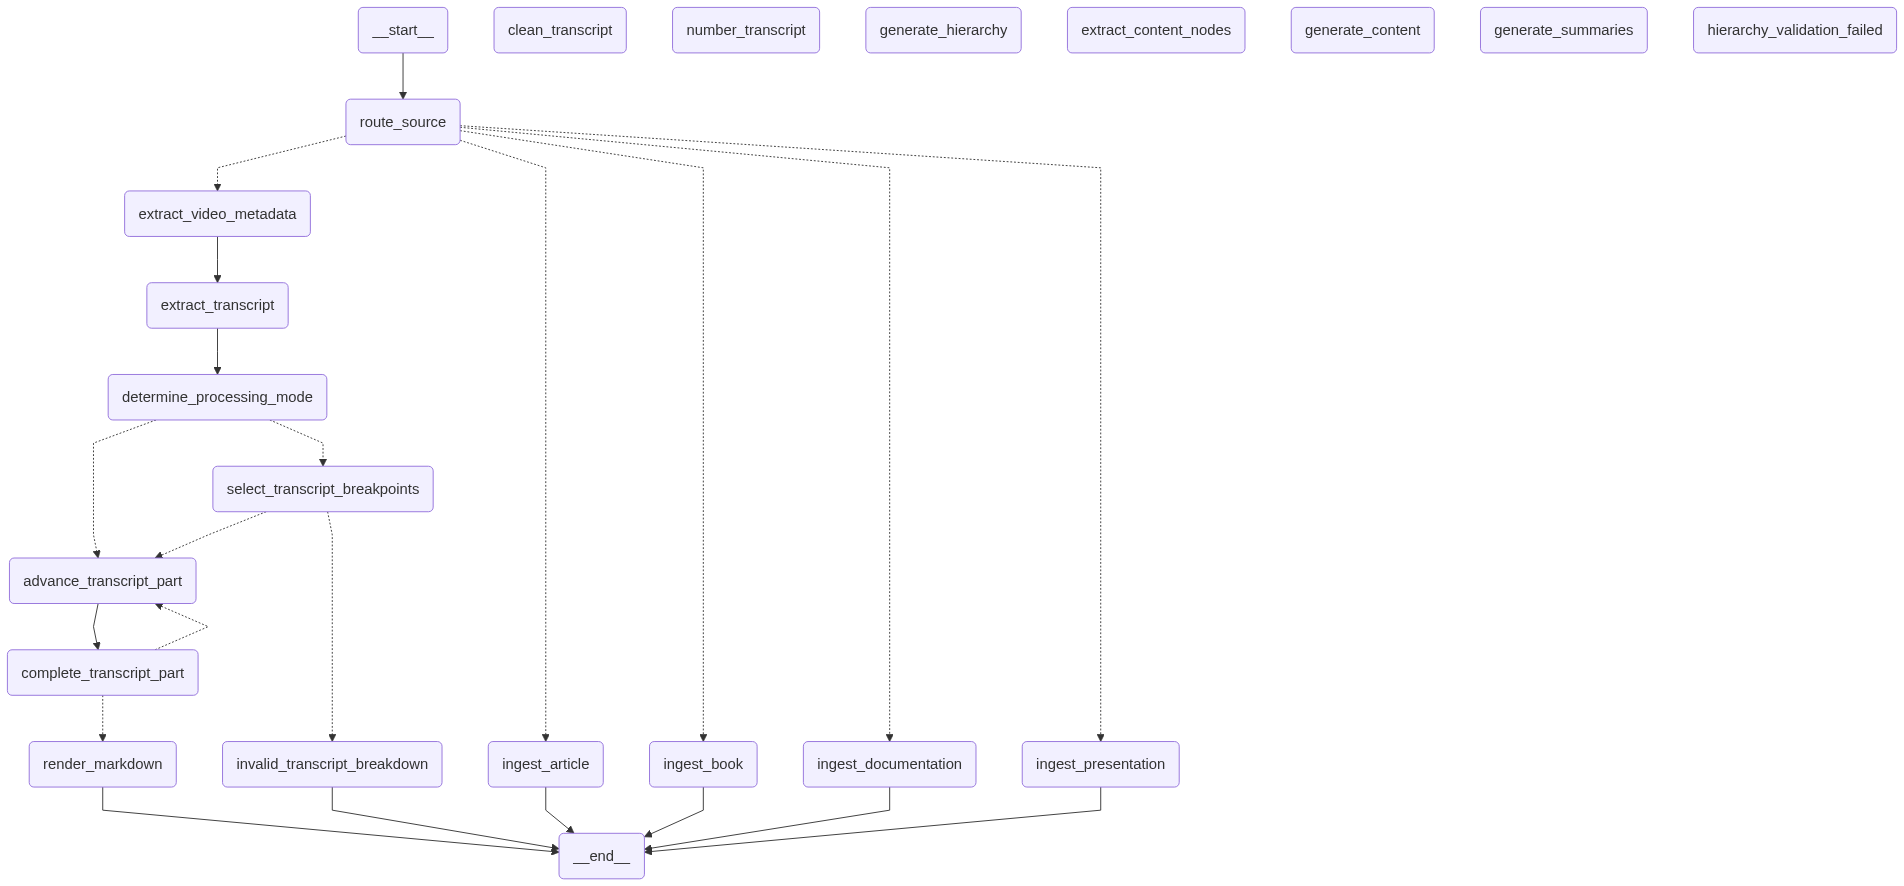

[INFO] Starting pipeline for source: https://www.youtube.com/watch?v=upblQZigz0U (type: youtube)
────────────────────────────────────────────────
⟳ Extracting Video Metadata
✓ Extracting Video Metadata
⟳ Downloading Transcript
✓ Downloading Transcript
⟳ Determining Processing Mode
· Transcript contains 74,324 tokens (limit 50,000). Multi-part processing required.
⟳ Waiting for User Selection
[INFO] Pipeline interrupted.

────────────────────────────────────────────────────────────────────────
  ⚡  Multi-Part Transcript Processing
────────────────────────────────────────────────────────────────────────
  Transcript size : 74,324 tokens
  Maximum per part: 50,000 tokens
  Chapters found  : 20
────────────────────────────────────────────────────────────────────────

  Available chapters:

    [00] 00:00:00 |  2,927 tokens | Introduction
    [01] 00:17:13 |  3,110 tokens | What is Agentic AI?
    [02] 00:36:19 |  1,644 tokens | Agentic AI vs Generative AI
    [03] 00:46:07 |  1,092 tokens 

Deserializing unregistered type deep_notes_ai.domain.models.SourceType from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('deep_notes_ai.domain.models', 'SourceType')]
Deserializing unregistered type deep_notes_ai.domain.models.VideoMetadata from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('deep_notes_ai.domain.models', 'VideoMetadata')]
Deserializing unregistered type deep_notes_ai.domain.models.ChapterTranscript from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('deep_notes_ai.domain.models', 'ChapterTranscript')]
Deserializing unregistered type deep_notes_ai.domain.models.TranscriptProcessingMode from checkpoint. This will be blocked in a future ve


  ✓ Selected breakpoint chapters:

    [08] 03:09:37 |  2,243 tokens | Transformers Neural Networks Explained

────────────────────────────────────────────────────────────────────────

⟳ Waiting for User Selection
✓ Waiting for User Selection
⟳ Preparing Transcript Part
· Processing part 1/2
· Raw content restored from cache
⟳ Completing Transcript Part
· Completed part 1/2. Next: part 2/2.
⟳ Preparing Transcript Part
· Processing part 2/2
· Raw content restored from cache
⟳ Completing Transcript Part
✓ Completing Transcript Part
⟳ Rendering Markdown
✓ Rendering Markdown
· Pipeline finished — notes ready.
[INFO] Pipeline completed successfully.

[INFO] Pipeline Final State
────────────────────────────────────────────────────────────────────────
  Source              : https://www.youtube.com/watch?v=upblQZigz0U
  Source Type         : youtube
  Content Base Dir    : /Users/govind/github_repos/deep-notes-knowledge-base/youtube/upblQZigz0U
  Content ID          : upblQZigz0U
  Content T

0

In [2]:
run_pipeline(
    youtube_url="https://www.youtube.com/watch?v=upblQZigz0U",
    source_type=SourceType.YOUTUBE
)


In [2]:
from deep_notes_ai.services.video_metadata_service import VideoMetadataService

content_id = "jGg_1h0qzaM"
metadata_service = VideoMetadataService()
metadata = metadata_service.fetch_metadata(content_id)

In [3]:
from deep_notes_ai.services.transcript_service import TranscriptService


transcript_service = TranscriptService()
chapters = transcript_service.fetch(content_id=metadata.id, chapters=metadata.chapters)

In [4]:
from pprint import pprint


pprint(chapters)

[ChapterTranscript(title='Introduction',
                   display='00:00',
                   transcript='Welcome to this video course on Langraph, the '
                              'powerful Python library for building advanced '
                              'conversational AI workflows. In this course, '
                              'Vbeca will teach you how to design, implement, '
                              'and manage complex dialogue systems using a '
                              "graph-based approach. By the end, you'll be "
                              'equipped to build robust, scalable, '
                              'conversational applications that leverage the '
                              'full potential of large language models. Hey '
                              "guys, my name is Vava and I'm a robotics and AI "
                              "student. In this course, we're going to be "
                              'learning all about the fundamentals of 